# D005 — 모두마켓 웹 로그 파싱 & 트래픽 리포트

**종합 실습:** 한 줄짜리 웹 서버 로그를 → 정규식 추출 → 날짜 파싱 → dt 부품 → 리샘플링 순으로 분석 가능한 표/그래프로 만든다.

> 처리 순서: **원본 관찰 → 정규식 파싱 → 날짜 변환 → 부품/집계 → 리샘플링** (오늘 Part 1~6 순서 그대로)

## 0. 환경 준비

In [1]:
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# 한글 폰트 (그래프 글자 깨짐 방지)
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)

print("준비 완료 | pandas:", pd.__version__)

준비 완료 | pandas: 3.0.2


## 1. 웹 로그 생성 (가상 데이터)

한 줄이 통째로 하나의 문자열이다. 흔한 웹 서버 로그 형식:
```
203.0.113.5 - - [12/Jan/2025:10:15:32] "GET /products/123 HTTP/1.1" 200 1024
   IP                접속 시각          방식  요청 경로         상태 크기
```

In [2]:
np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

웹 로그 생성 완료: (1500, 1)

[원본 로그 한 줄은 이렇게 생겼습니다]
203.0.113.39 - - [01/Mar/2025:00:01:14] "GET / HTTP/1.1" 200 2371
198.51.100.21 - - [01/Mar/2025:00:02:24] "GET / HTTP/1.1" 301 284
198.51.100.17 - - [01/Mar/2025:00:02:28] "GET /search HTTP/1.1" 200 1448


## 시나리오 1 — 원본 관찰 + 정규식 파싱

`.str.extract()`에 **이름 붙은 그룹** `(?P<이름>패턴)`을 쓰면 각 그룹이 그 이름의 컬럼이 되어 한 번에 표가 만들어진다.

In [3]:
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"   # IP: 숫자.숫자.숫자.숫자
    r" - - \["                          # 고정 구분 부분
    r"(?P<ts>[^\]]+)"                    # 시각: ] 가 아닌 글자들
    r"\] \""                            # ] 와 따옴표
    r"(?P<method>\w+) "                  # 방식: GET/POST
    r"(?P<path>\S+)"                     # 경로: 공백 아닌 글자들
    r"[^\"]*\" "                        # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                  # 상태 코드
    r"(?P<size>\d+)"                     # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern)
print("추출된 표:", logs.shape)
print("추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())
logs.head()

추출된 표: (1500, 6)
추출 실패(어느 한 칸이라도 NaN) 행 수: 0


,ip,ts,method,path,status,size
0,203.0.113.39,01/Mar/2025:00:01:14,GET,/,200,2371
1,198.51.100.21,01/Mar/2025:00:02:24,GET,/,301,284
2,198.51.100.17,01/Mar/2025:00:02:28,GET,/search,200,1448
3,203.0.113.35,01/Mar/2025:00:03:56,GET,/cart,404,3921
4,203.0.113.47,01/Mar/2025:00:14:29,GET,/products,500,2580


## 시나리오 2 — 날짜 변환 + 타입 정리 + dt 부품

추출한 `ts`는 아직 문자열(`12/Jan/2025:10:15:32`), `status`·`size`도 문자열이다.
`%d/%b/%Y:%H:%M:%S` 형식으로 파싱한다. (`%b` = `Jan`·`Feb` 같은 영문 월 약자)

In [4]:
logs["ts"] = pd.to_datetime(logs["ts"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
logs["status"] = logs["status"].astype(int)
logs["size"] = logs["size"].astype(int)

# dt 부품: 시각(hour) + 요일
logs["hour"] = logs["ts"].dt.hour
logs["dow_name"] = logs["ts"].dt.day_name()

print("정리 후 자료형:")
print(logs.dtypes)
print("\n날짜 파싱 실패 건수:", logs["ts"].isna().sum())
logs[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].head()

정리 후 자료형:
ip                     str
ts          datetime64[us]
method                 str
path                   str
status               int64
size                 int64
hour                 int32
dow_name               str
dtype: object

날짜 파싱 실패 건수: 0


,ip,ts,method,path,status,hour,dow_name
0,203.0.113.39,2025-03-01 00:01:14,GET,/,200,0,Saturday
1,198.51.100.21,2025-03-01 00:02:24,GET,/,301,0,Saturday
2,198.51.100.17,2025-03-01 00:02:28,GET,/search,200,0,Saturday
3,203.0.113.35,2025-03-01 00:03:56,GET,/cart,404,0,Saturday
4,203.0.113.47,2025-03-01 00:14:29,GET,/products,500,0,Saturday


### 시나리오 2 — 상태 코드 · 오류율 · 인기 경로

In [5]:
print("[상태 코드 분포]")
print(logs["status"].value_counts())

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율 (불리언의 mean = 참의 비율)
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head())

[상태 코드 분포]
status
200    964
301    188
404    178
500    170
Name: count, dtype: int64

오류 응답(4xx·5xx) 비율: 23.2%

[요청이 많은 경로 TOP 5]
path
/                184
/search          175
/cart            173
/products/456    171
/products        168
Name: count, dtype: int64


## 시나리오 3 — 리샘플링으로 시간대별 트래픽

`ts`를 인덱스로 올리고 시간 단위(`"h"`)로 묶어 시간당 요청 수를 집계·시각화한다.

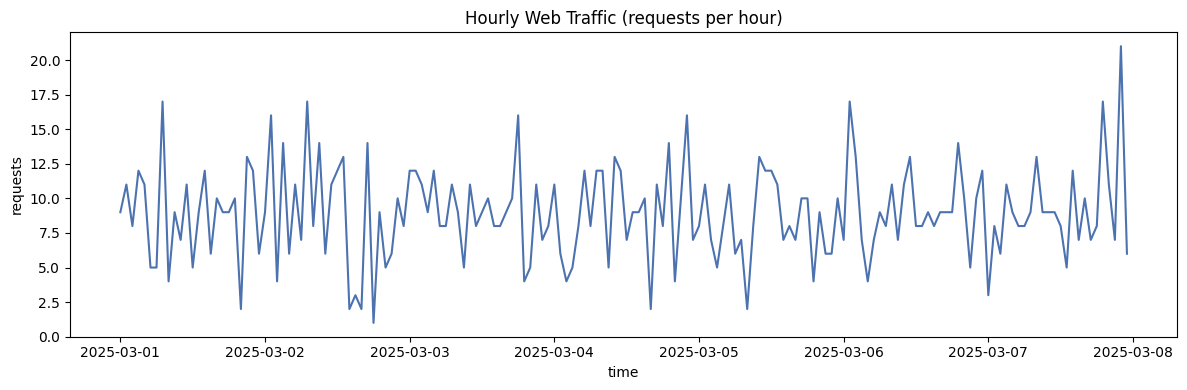

가장 트래픽이 많았던 시간대 TOP 3:
ts
2025-03-07 22:00:00    21
2025-03-01 07:00:00    17
2025-03-06 01:00:00    17
Name: ip, dtype: int64


In [6]:
log_ts = logs.dropna(subset=["ts"]).set_index("ts").sort_index()
hourly_traffic = log_ts["ip"].resample("h").count()   # 시간당 요청 수

plt.figure(figsize=(12, 4))
plt.plot(hourly_traffic.index, hourly_traffic.values, color="#4C72B0")
plt.title("Hourly Web Traffic (requests per hour)")
plt.xlabel("time"); plt.ylabel("requests")
plt.tight_layout(); plt.show()

print("가장 트래픽이 많았던 시간대 TOP 3:")
print(hourly_traffic.sort_values(ascending=False).head(3))

### (참고) 시(hour)대별 · 요일별 집계 — 리포트 4번 항목용

In [7]:
print("[시(hour)대별 총 요청 수 TOP 5 - 요일 무관, 시각만]")
print(logs.groupby("hour").size().sort_values(ascending=False).head(5))

print("\n[요일별 요청 수]")
print(logs["dow_name"].value_counts())

[시(hour)대별 총 요청 수 TOP 5 - 요일 무관, 시각만]
hour
22    82
1     81
7     81
11    76
19    72
dtype: int64

[요일별 요청 수]
dow_name
Thursday     225
Monday       221
Friday       221
Tuesday      215
Saturday     212
Sunday       208
Wednesday    198
Name: count, dtype: int64


## 심화 (선택) — 비정상 IP / 오류 잦은 경로

정답이 있는 게 아니라 **판단 근거**가 핵심.

In [8]:
print("[요청 많은 IP TOP 5]")
print(logs["ip"].value_counts().head(5))

print("\n[오류 응답(4xx·5xx)이 잦은 경로 TOP 3]")
err_logs = logs[logs["status"] >= 400]
print(err_logs["path"].value_counts().head(3))

[요청 많은 IP TOP 5]
ip
198.51.100.41    24
203.0.113.58     21
198.51.100.52    19
203.0.113.27     19
203.0.113.18     19
Name: count, dtype: int64

[오류 응답(4xx·5xx)이 잦은 경로 TOP 3]
path
/checkout    45
/            44
/cart        43
Name: count, dtype: int64


---
# 📊 웹 트래픽 리포트 (제출물)

> ⚠️ 아래 리포트에서 **사실 숫자는 위 셀 실행 결과로 채워 두었습니다.**
> **`[👉 직접 작성]` 표시가 붙은 부분(4번 특징 해석, 5번 다음 분석 제안, 심화 판단 근거)은 훈이 직접 채우세요.** 여기가 평가의 핵심입니다.

## 1. 데이터 개요
- 로그 줄 수: **1,500줄**
- 기간: **2025-03-01 00:01 ~ 2025-03-07 23:42** (7일치)
- 추출 필드: ip, ts, method, path, status, size

## 2. 파싱 (어떻게 표로 만들었나)
- 사용한 정규식 핵심: IP는 `\d+\.\d+\.\d+\.\d+`, 시각은 `[^\]]+`(`]` 전까지), 상태·크기는 `\d+`로 추출
- 이름 붙은 그룹 `(?P<이름>...)`으로 6개 컬럼을 한 번에 생성 → **추출 실패 0건**
- 날짜 형식: `%d/%b/%Y:%H:%M:%S`로 파싱, **파싱 실패 0건**

## 3. 트래픽 요약
- 총 요청 수: **1,500건**
- 상태 코드 분포: 200=964, 301=188, 404=178, 500=170
- 오류 응답(4xx·5xx) 비율: **23.2%** (404 + 500 = 348건)
- 요청 많은 경로 TOP 3: **`/` (184) → `/search` (175) → `/cart` (173)**

## 4. 시간 패턴 (리샘플링에서 읽은 것)
- 트래픽이 가장 몰린 시간대(hour 기준): **22시(82건)**, 그다음 1시·7시(각 81건)
- 요일별 요청 수: Thursday(225)가 최다, Wednesday(198)가 최소 — 대체로 고른 편
- 요일/시간대 특징 해석: **[👉 직접 작성]** _예: 심야(1시)·아침(7시)·밤(22시)에 고르게 몰리는데, 이게 실제 사용자 패턴인지 무작위 생성 탓인지 생각해서 한 줄._

## 5. 다음 분석 제안
- **[👉 직접 작성]** _아래 심화 결과를 근거로, 운영팀에 무엇을 제안할지 2~3줄. (예: 오류율 23%는 높다 → `/checkout` 오류 집중 점검 등)_

---
### 심화 (선택)
- 요청 많은 IP TOP: 198.51.100.41(24건), 203.0.113.58(21건) …
  - 비정상 IP 판단: **[👉 직접 작성]** _최다 24건인데 총 1,500건 / IP 118개면 평균 약 12.7건. 24건이 "비정상"이라 볼 만한 수준인지 근거와 함께._
- 오류 잦은 경로 TOP 3: **`/checkout`(45) → `/`(44) → `/cart`(43)**
  - 운영 제안: **[👉 직접 작성]** _`/checkout`은 결제 단계라 오류가 매출에 직결 → 우선 점검 제안, 등._